In [59]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [60]:
#Load dataset
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Data Overview

In [61]:
#Dataset shape
df.shape

(8807, 12)

In [62]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [63]:
#Statistical information
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [64]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Cleaning

In [65]:
#Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [66]:
#Fill missing value
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df = df.dropna(subset=['duration'])

In [67]:
#Convert date format
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [68]:
df_copy = df.copy()

Movies vs TV Shows Distribution

In [69]:
df['type'].value_counts()

type
Movie      6128
TV Show    2676
Name: count, dtype: int64

Graph

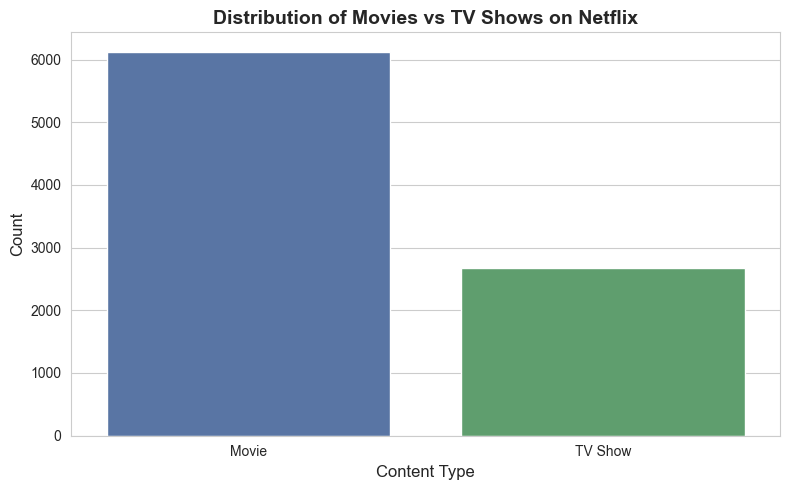

In [70]:
plt.figure()
sns.countplot(x='type',data=df,hue='type',palette=['#4C72B0','#55A868'],legend=False)

plt.title("Distribution of Movies vs TV Shows on Netflix", fontweight='bold')
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Top 10 Countries

In [71]:
#top 10 countries
top_countries=df['country'].value_counts().head(10)
top_countries

country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Graph

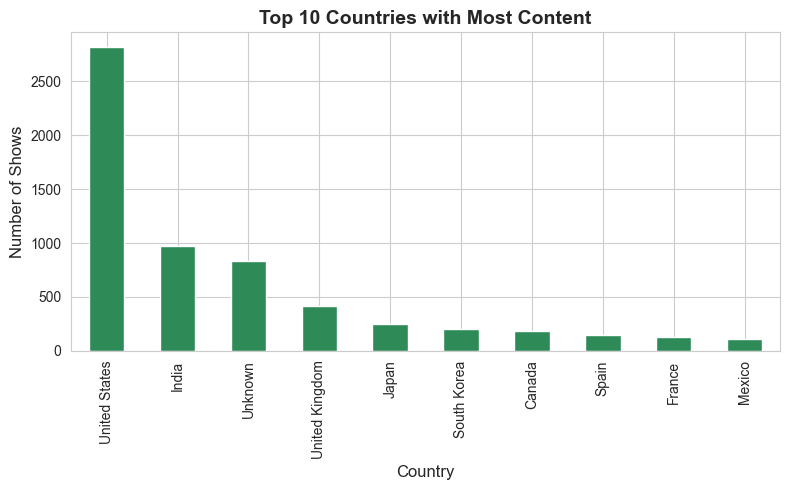

In [72]:
plt.figure()
top_countries.plot(kind='bar', color='#2E8B57')
plt.title("Top 10 Countries with Most Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()

Genre Analysis

In [73]:
#Split genres
df_copy['listed_in'] = df_copy['listed_in'].str.split(',')

# Explode to separate rows
genres = df_copy.explode('listed_in')

# Remove extra spaces
genres['listed_in'] = genres['listed_in'].str.strip()

# Top 10 genres
top_genres = genres['listed_in'].value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Graph

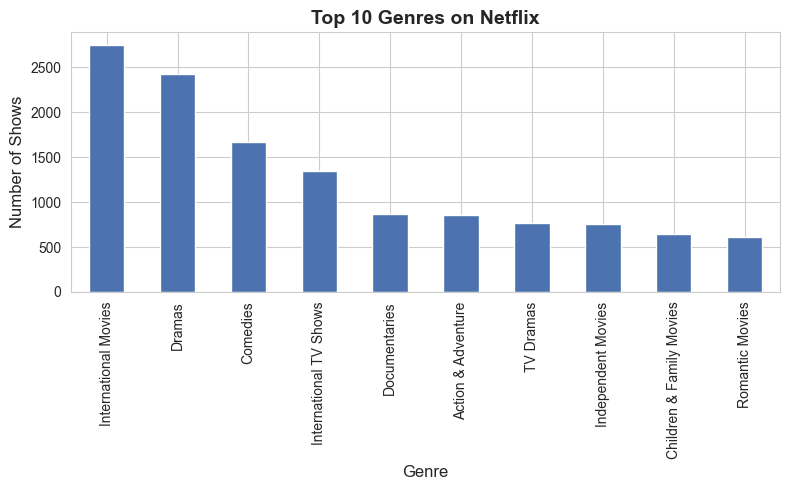

In [74]:
plt.figure()
top_genres.plot(kind='bar',color='#4C72B0')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()

Top Directors

In [75]:
#top 10 directors
top_directors=df['director'].value_counts().head(10)
top_directors

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64

Graph

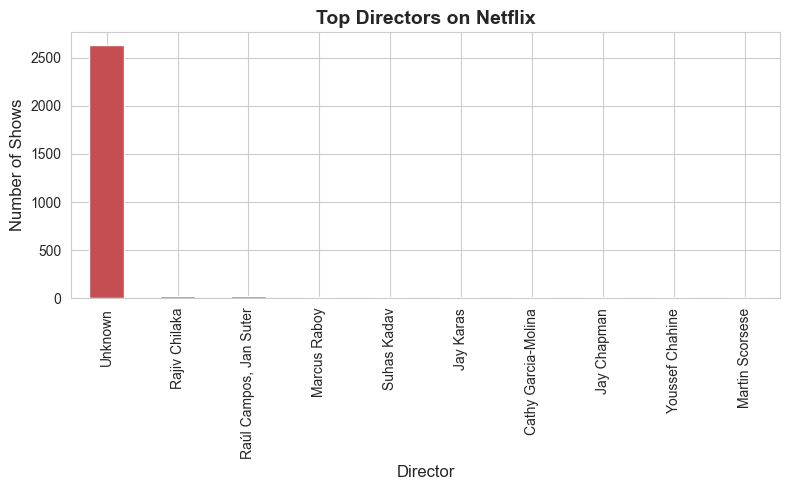

In [76]:
plt.figure()
top_directors.plot(kind='bar', color='#C44E52')
plt.title("Top Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()

Content Added per Month

In [77]:
#extract month
df['month_added']=df['date_added'].dt.month_name()

In [78]:
#Count
df['month_added'].value_counts()

month_added
July         827
December     813
September    769
April        763
October      760
August       754
March        742
January      738
June         728
November     705
May          632
February     563
Name: count, dtype: int64

Graph

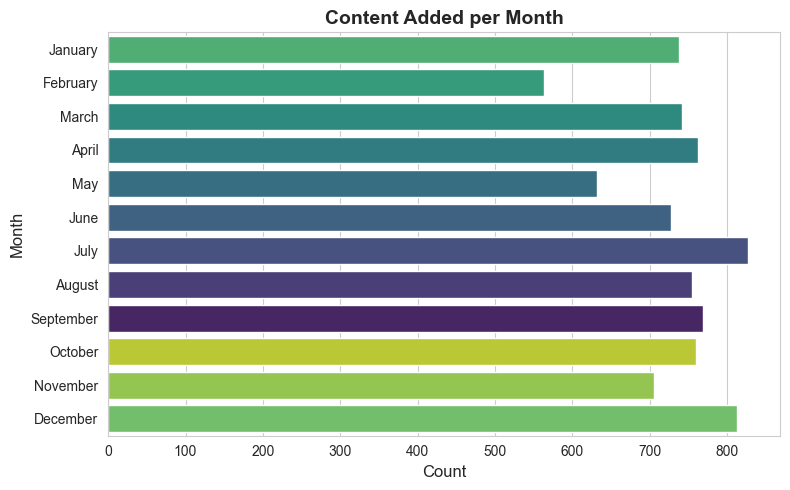

In [79]:

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure()
sns.countplot(y='month_added',data=df,order=month_order,hue='month_added',palette='viridis',legend=False)
plt.title("Content Added per Month", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

Movie Duration Analysis

In [80]:
#Movies filter
movies=df[df['type']=='Movie'].copy()

In [81]:
#Duration Extract
movies['duration_int'] = movies['duration'].str.extract(r'(\d+)')[0].astype(float)
print(movies['duration_int'].head())

0      90.0
6      91.0
7     125.0
9     104.0
12    127.0
Name: duration_int, dtype: float64


Graph

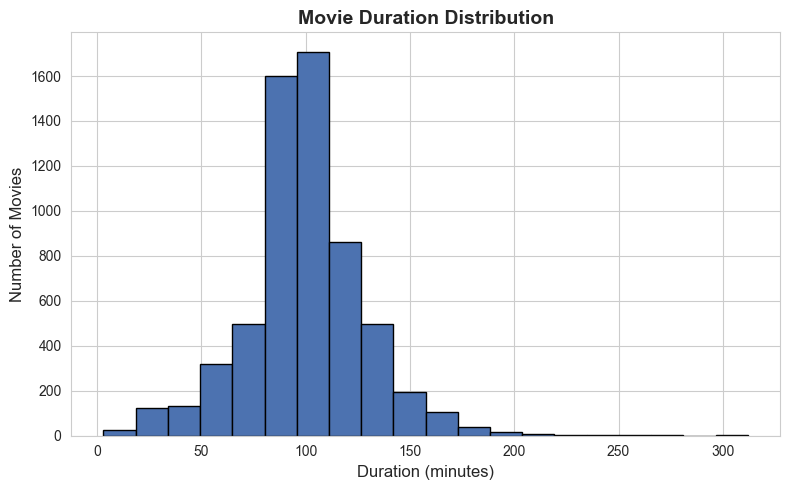

In [82]:

clean_duration = movies['duration_int'].dropna()

plt.figure()
plt.hist(clean_duration,bins=20,color='#4C72B0',edgecolor='black')   

plt.title("Movie Duration Distribution", fontweight='bold')
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

Rating Distribution

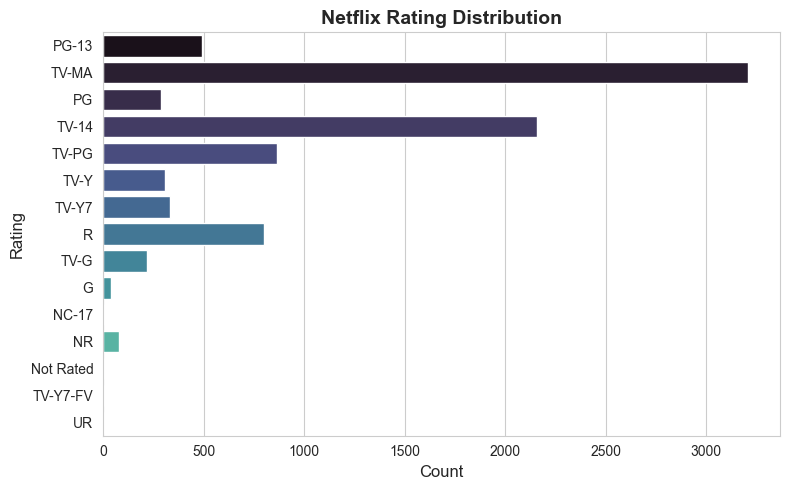

In [83]:
#Graph
plt.figure()

sns.countplot(y='rating',data=df,hue='rating',palette='mako',legend=False)

plt.title("Netflix Rating Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

Content Release Trend

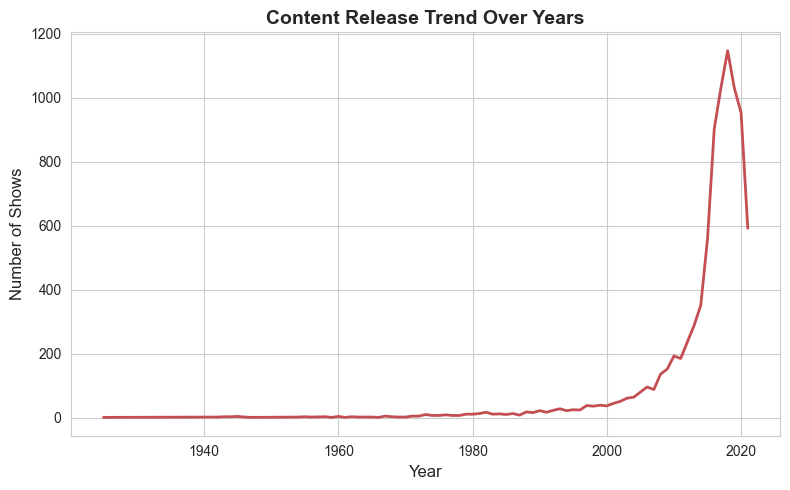

In [84]:
#Graph
plt.figure()

df['release_year'].value_counts().sort_index().plot(color='#C44E52',linewidth=2)

plt.title("Content Release Trend Over Years", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.tight_layout()
plt.show()

Top 10 Actors

In [85]:
# Split cast
df_copy['cast'] = df_copy['cast'].str.split(',')

# Explode actors
actors = df_copy.explode('cast')

# Remove extra spaces
actors['cast'] = actors['cast'].str.strip()

# Remove unknown values
actors = actors[actors['cast'] != 'Unknown']

# Top 10 actors
top_actors = actors['cast'].value_counts().head(10)
top_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

Graph

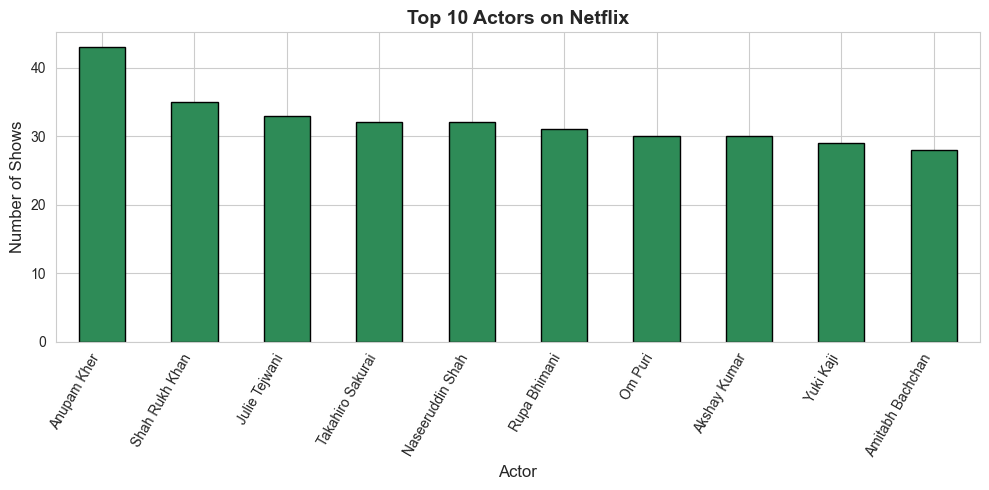

In [88]:

plt.figure(figsize=(10,5))

top_actors.plot(kind='bar',color='#2E8B57',edgecolor='black')

plt.title("Top 10 Actors on Netflix", fontweight='bold')
plt.xlabel("Actor")
plt.ylabel("Number of Shows")

plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Business Insights

Key Insights:

- Netflix has more Movies than TV Shows.
- The United States produces the highest number of titles.
- Drama and International Movies are the most common genres.
- Most movies have a duration between 90–120 minutes.
- Content addition increased significantly after 2015.